In [ ]:
import anndata

import dtangle

In [26]:
# Load dataset
adata_mix = anndata.read_h5ad("./data/brain_aging_microarray.h5ad")
adata_ref = anndata.read_h5ad("./data/brain_single_cell.h5ad")
adata_mix.var_names_make_unique()
adata_ref.var_names_make_unique()

/home/malte/Dokumente/Github/dtangle/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [27]:
# Find common genes
common_genes = adata_mix.var_names.intersection(adata_ref.var_names)
adata_mix = adata_mix[:, common_genes].copy()
adata_ref = adata_ref[:, common_genes].copy()

In [28]:
ct_col = "cell_type"
pure_samples = (
    adata_ref.obs.reset_index(names="obs_name").groupby(ct_col, observed=False)["obs_name"].apply(list).to_dict()
)

In [29]:
dtangle.deconvolut(
    adata_mix,
    references=adata_ref,
    pure_samples=pure_samples,
    data_type="microarray-gene",
    key_added="dtangle_sc",
)

adata_mix.obsm["dtangle_sc"].head()

,Neurons,Neuroblast,Astrocytes,Oligodendrocytes,Oligodendrocyte precursor cells,Microglia
GSM1303144_24M.CEL,0.385471,0.157636,0.128135,0.087965,0.130750,0.110044
GSM1303145_25BF.CEL,0.373632,0.158939,0.135272,0.088278,0.134050,0.109829
GSM1303146_25F.CEL,0.372604,0.154251,0.146045,0.091005,0.131120,0.104975
GSM1303147_26BM.CEL,0.356444,0.152652,0.157790,0.091801,0.129604,0.111709
GSM1303148_26M.CEL,0.357495,0.153784,0.141635,0.101902,0.129315,0.115869


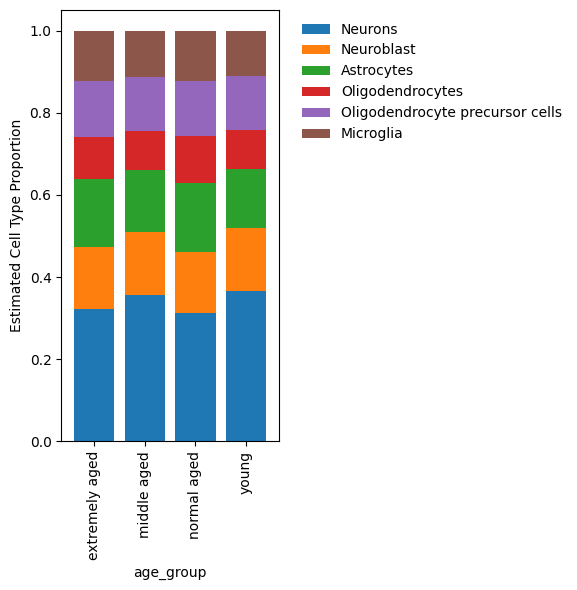

In [39]:
import matplotlib.pyplot as plt

proportions = adata_mix.obsm["dtangle_sc"].copy()
proportions["age_group"] = adata_mix.obs["age_group"].values
proportions = proportions.groupby("age_group", observed=True).mean()
proportions.plot(kind="bar", stacked=True, figsize=(6, 6), width=0.8)
plt.ylabel("Estimated Cell Type Proportion")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", frameon=False)
plt.tight_layout()
plt.show()

/tmp/ipykernel_18779/1034299617.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


[Text(0, 0, 'Neurons'),
 Text(1, 0, 'Neuroblast'),
 Text(2, 0, 'Astrocytes'),
 Text(3, 0, 'Oligodendrocytes'),
 Text(4, 0, 'Oligodendrocyte precursor cells'),
 Text(5, 0, 'Microglia')]

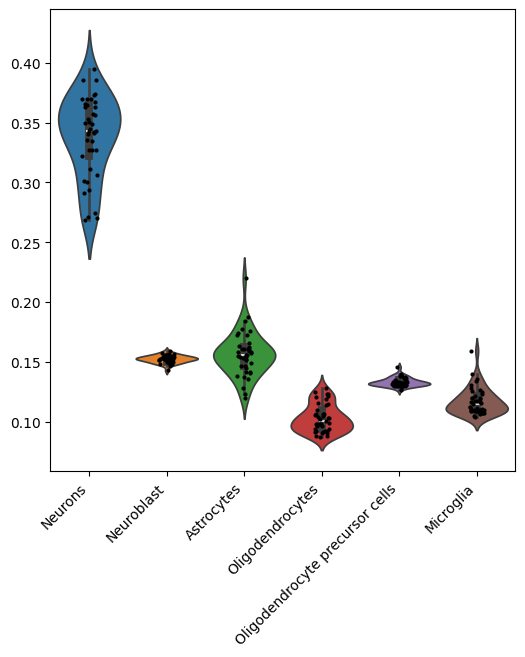

In [40]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(6, 6))
sns.violinplot(adata_mix.obsm["dtangle_sc"], ax=ax)
sns.stripplot(adata_mix.obsm["dtangle_sc"], color="k", size=3, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")